In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1791034204.640513    1986 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791034204.933871    1986 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791034212.265153    1986 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
df = pd.read_csv("gas_turbines.csv")
print("Shape:", df.shape)
print(df.head())
print(df.describe())
print("Missing values:\n", df.isnull().sum())

Shape: (15039, 11)
       AT      AP      AH    AFDP    GTEP     TIT     TAT     TEY     CDP  \
0  6.8594  1007.9  96.799  3.5000  19.663  1059.2  550.00  114.70  10.605   
1  6.7850  1008.4  97.118  3.4998  19.728  1059.3  550.00  114.72  10.598   
2  6.8977  1008.8  95.939  3.4824  19.779  1059.4  549.87  114.71  10.601   
3  7.0569  1009.2  95.249  3.4805  19.792  1059.6  549.99  114.72  10.606   
4  7.3978  1009.7  95.150  3.4976  19.765  1059.7  549.98  114.72  10.612   

       CO     NOX  
0  3.1547  82.722  
1  3.2363  82.776  
2  3.2012  82.468  
3  3.1923  82.670  
4  3.2484  82.311  
                 AT           AP            AH          AFDP          GTEP  \
count  15039.000000  15039.00000  15039.000000  15039.000000  15039.000000   
mean      17.764381   1013.19924     79.124174      4.200294     25.419061   
std        7.574323      6.41076     13.793439      0.760197      4.173916   
min        0.522300    985.85000     30.344000      2.087400     17.878000   
25%     

In [3]:
FEATURES = ["AT", "AP", "AH", "AFDP"]   # ambient variables
TARGET   = "TEY"

X = df[FEATURES].values
y = df[TARGET].values.reshape(-1, 1)

print("X shape:", X.shape, "| y shape:", y.shape)

X shape: (15039, 4) | y shape: (15039, 1)


In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (10527, 4), Val: (2256, 4), Test: (2256, 4)


In [5]:
scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train)

X_train_s = scaler_X.transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

y_train_s = scaler_y.transform(y_train)
y_val_s   = scaler_y.transform(y_val)
y_test_s  = scaler_y.transform(y_test)

In [6]:
def build_model(input_dim):
    model = Sequential([
        Dense(64, activation="relu", input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.2),

        Dense(32, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),

        Dense(16, activation="relu"),

        Dense(1, activation="linear")   # regression output
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )
    return model

model = build_model(X_train_s.shape[1])
model.summary()

/home/dd21271c-506b-4fd2-9648-caa95b8510da/.local/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1791034280.731801    1986 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 192 (768.00 B)

In [9]:
early_stop = EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6
)

history = model.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=200,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=2
)

Epoch 1/200
42/42 - 2s - 43ms/step - loss: 0.3006 - mae: 0.3863 - val_loss: 0.2853 - val_mae: 0.3626 - learning_rate: 3.1250e-05
Epoch 2/200
42/42 - 2s - 42ms/step - loss: 0.3084 - mae: 0.3919 - val_loss: 0.2855 - val_mae: 0.3630 - learning_rate: 3.1250e-05
Epoch 3/200
42/42 - 2s - 44ms/step - loss: 0.3063 - mae: 0.3921 - val_loss: 0.2854 - val_mae: 0.3628 - learning_rate: 3.1250e-05
Epoch 4/200
42/42 - 2s - 40ms/step - loss: 0.3053 - mae: 0.3894 - val_loss: 0.2852 - val_mae: 0.3627 - learning_rate: 3.1250e-05
Epoch 5/200
42/42 - 2s - 38ms/step - loss: 0.3071 - mae: 0.3901 - val_loss: 0.2850 - val_mae: 0.3623 - learning_rate: 3.1250e-05
Epoch 6/200
42/42 - 1s - 26ms/step - loss: 0.3064 - mae: 0.3898 - val_loss: 0.2853 - val_mae: 0.3626 - learning_rate: 3.1250e-05
Epoch 7/200
42/42 - 1s - 26ms/step - loss: 0.3072 - mae: 0.3895 - val_loss: 0.2854 - val_mae: 0.3629 - learning_rate: 3.1250e-05
Epoch 8/200
42/42 - 1s - 29ms/step - loss: 0.3069 - mae: 0.3906 - val_loss: 0.2855 - val_mae: 0.3

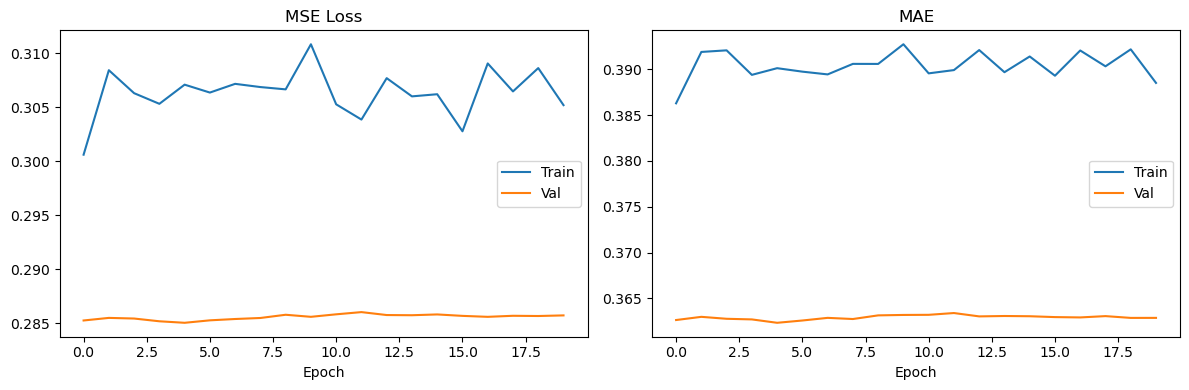

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history.history["loss"], label="Train")
ax[0].plot(history.history["val_loss"], label="Val")
ax[0].set_title("MSE Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend()

ax[1].plot(history.history["mae"], label="Train")
ax[1].plot(history.history["val_mae"], label="Val")
ax[1].set_title("MAE"); ax[1].set_xlabel("Epoch"); ax[1].legend()

plt.tight_layout(); plt.show()

In [11]:
y_pred_s = model.predict(X_test_s)
y_pred   = scaler_y.inverse_transform(y_pred_s)
y_true   = scaler_y.inverse_transform(y_test_s)

mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
MSE  : 73.0268
RMSE : 8.5456
MAE  : 5.8141
R²   : 0.7228


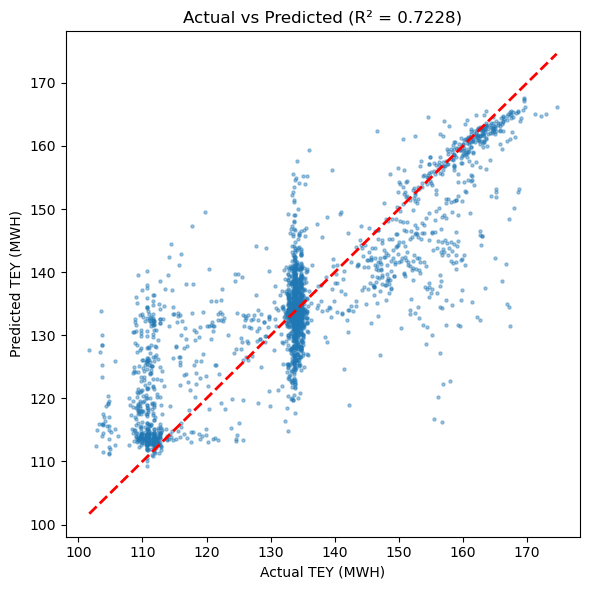

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, s=5, alpha=0.4)
lims = [y_true.min(), y_true.max()]
plt.plot(lims, lims, "r--", linewidth=2)
plt.xlabel("Actual TEY (MWH)")
plt.ylabel("Predicted TEY (MWH)")
plt.title(f"Actual vs Predicted (R² = {r2:.4f})")
plt.tight_layout(); plt.show()

In [13]:
import joblib

model.save("tey_nn_model.keras")
joblib.dump(scaler_X, "scaler_X.pkl")
joblib.dump(scaler_y, "scaler_y.pkl")
print("Model and scalers saved.")

Model and scalers saved.
